<a href="https://colab.research.google.com/github/Solomon-Million/Semantic-Segmentation-of-Liver-and-Its-Tumor-Using-3D-U-Net/blob/main/Semantic%20Segmentation%20of%20Liver%20and%20Its%20Tumor%20Using%203D%20U-Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semantic Segmentation of Liver and Its Tumor Using 3D U-Net
Million Solomon  
*dept. Electrical and Computer Engineering*  
*Toronto Metropolitan University*  
Toronto, Canada  
million.solomon@torontomu.ca


# Abstract

In this study, I explore an experimental modification
of the U-Net model tailored for segmenting liver and its lesions in
contrast-enhanced abdominal CT scans. This adaptation employs
a unique combination of Dice Loss and Focal Loss aimed at
addressing the challenge of class imbalance between foreground
lesions and background voxels. My preprocessing approach
involves excluding training examples where the segmentation
mask is predominantly background by over 95 percent, thus
concentrating the model's learning on clinically significant cases.
Validated on the LiTS 2017 dataset, this customized adaptation
of the U-Net model illustrates its potential in medical image
segmentation. However, it achieved moderate accuracy of 65.34%
and Intersection over Union (IoU) of 34.85%, indicating areas
for further improvement and optimization in future work.



---



---


# Steps to Access the Shared "LiTS Challenge" Folder in Google Colab
# Follow these steps to do so:



1.   Open Your Google Drive:
  *   Go to Google Drive.
  *  Navigate to the "Shared with me" section found in the left-hand panel.


2.   Locate the Shared Folder:
  *   Find the "LiTS Challenge" folder that has been shared with you.
3.   Add a Shortcut to Your Drive:
  *   Right-click on the "LiTS Challenge" folder.
  *   Select "Organize==>Add shortcut to Drive".
  *   place it directly in "My Drive".
  *   Click "Add Shortcut".

MEMORY REQUIREMENT: This is a memory intensive code. You need at least 51GB of
System RAM to run the code.










# Data import and Preprocessing


In [ ]:
!pip install segmentation-models-3D  # Installs the segmentation-models-3D package for 3D image segmentation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 7.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 33.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.8/489.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.7/479.7 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 74.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 96.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
#tensorflow should be 2.x versions. 2.13 is used
# importing necessary libraries and modules
import os
import csv
import random
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import glob
from keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Mounting Google Drive  
Mounting Google Drive as a filesystem, and setting up paths to access Training and Test datasets stored in Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')   # mounting my google drive, YOU WILL NEED ACESS PERMISSION FOR MY DRIVE.

os.makedirs('/content/LITS_train/img/', exist_ok=True)
os.makedirs('/content/LITS_train/img_segm/', exist_ok=True)
os.makedirs('/content/LITS_test/img_test/', exist_ok=True)
os.makedirs('/content/LITS_test/img_segm_test/', exist_ok=True)
os.makedirs('/content/Model/', exist_ok=True)


train_path = '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/'  # Saving our training set's path
test_path = '/content/gdrive/MyDrive/LITS Challenge/Testing Batch 1/'   # Saving our testing set's path

Mounted at /content/gdrive


# Getting familiar with our dataset

In [ ]:
# Checking what our data looks like
# Let's take for example 'volume-30', and its segmantation: 'segmentation-30'
#The image data is then scaled using MinMaxScaler from scikit-learn,
# which normalizes the pixel intensities to a range between 0 and 1.
# The image is first reshaped to 2D because MinMaxScaler expects a 2D array (-1 in the reshape method means "infer this dimension").
#After scaling, it's reshaped back to its original 3D shape.

img = nib.load(train_path + 'volume-30.nii').get_fdata()
print(img.shape)
print(img.max())
img = scaler.fit_transform(img.reshape(-1, img.shape[-1])).reshape(img.shape)
print(img.max())
print(img.shape)
img_segm = nib.load(train_path + 'segmentation-30.nii').get_fdata()
img_segm = img_segm.astype(np.uint8)
print(np.unique(img_segm))  # Here we can see there are the 3 specified classes: 0 -> liver, 1 -> tumor, 2 -> everything else/background
print(img_segm.shape)


(512, 512, 200)
3071.0
1.0
(512, 512, 200)
[0 1 2]
(512, 512, 200)


# Let's showcase these two images to observe how the data segmentation was performed earlier

200
106


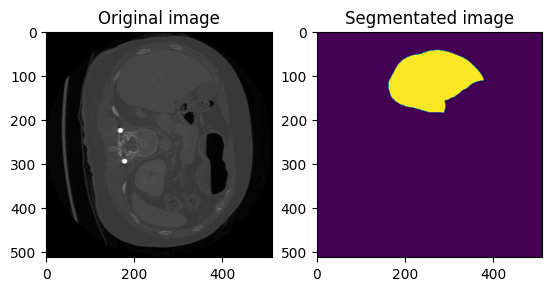

In [ ]:
# Most of the images were only made of "Everything else" pixels or the background)
n = random.randint(0, img.shape[2])  #  generates a random image number
print(img.shape[2])
print(n)

plt.figure(1)
plt.subplot(121)
plt.imshow(img[:,:,n], cmap='gray')
plt.title('Original image')
plt.subplot(122)
plt.imshow(img_segm[:,:,n])
plt.title('Segmentated image')
plt.show()




# Proccessing the Entire Data Set  
**Note:**This operation is memory-intensive. potentially up to 51GB of RAM is needed.

In [ ]:
# We aim to process the complete dataset, encompassing both the training and testing segments. Our approach entails:
# slicing to 256x256x64 dimensions. This operation is memory-intensive. potentially up to 51GB of RAM, to process the data effectively
#  1.Iterating over each '.nii' file.
#  2.Applying scaling to the images.
#  3.Ensuring each segmented image is rich in meaningful information, avoiding images dominated by a single class (such as backgrounds or liver-only scenes).
#  For the training portion, our focus is on utilizing images that incorporate all classes - liver, tumor, and background
# - to foster a more comprehensive training environment.
#  4.Archiving the pertinent data.

img_list = sorted(glob.glob(train_path + "volume*"))  # We sorted it so that original volumes will match the segmentated images
img_segm_list = sorted(glob.glob(train_path + "segmentation*"))
print(len(img_list), len(img_segm_list))  # We should have the same number of images
print(img_list)
print(img_segm_list)

testing_list = sorted(glob.glob(test_path + "volume*"))
testing_segm_list = sorted(glob.glob(test_path + "segmentation*"))
print(len(testing_list), len(testing_segm_list))

#  Selecting our training data
for i in range(len(img_list)):
  tmp = nib.load(img_list[i]).get_fdata()
  tmp = scaler.fit_transform(tmp.reshape(-1, tmp.shape[-1])).reshape(tmp.shape)

  tmp_segm = nib.load(img_segm_list[i]).get_fdata()
  tmp_segm = tmp_segm.astype(np.uint8)  # Converting values from float type to int type (here we should only have integer values)

  # Slicing the volume and segmentation mask to a specific size.
  # Here, we're slicing to 256x256x64 dimensions. This operation is memory-intensive. 51GB RAM is needed.
  # Note: Slicing to smaller than the current dimensions will require less than 12GB of RAM.
  # potentially up to 51GB of RAM is needed to process the data effectively.
  tmp=tmp[128:384, 128:384, 1:65]  #256x256x64
  tmp = np.expand_dims(tmp, axis=-1)
  tmp_segm = tmp_segm[128:384, 128:384, 1:65]

  # Tallying the unique values per class to assess
  #if a given image has a sufficient amount of pertinent information
  val, counts = np.unique(tmp_segm, return_counts=True)

  if (counts[0] / counts.sum()) < 0.95:    # Should the count of 0's exceed 95% of the mask, the file will be excluded from saving. If not, it will be preserved.
      tmp_segm = to_categorical(tmp_segm, num_classes=3)
      print(tmp_segm.shape)
      print(tmp.shape)
      np.save('/content/LITS_train/img/volume_'+str(i)+'.npy', tmp)
      np.save('/content/LITS_train/img_segm/segmentation_'+str(i)+'.npy', tmp_segm)

41 41
['/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-0.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-1.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-10.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-11.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-12.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-13.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-14.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-15.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-16.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-17.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-18.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-19.nii', '/content/gdrive/MyDrive/LITS Challenge/Training Batch 1/volume-2.nii', '/content/gdrive/MyDrive/LITS Challenge/Trainin

In [ ]:
# Selecting our testing data

for i in range(len(testing_list)):
  tmp = nib.load(testing_list[i]).get_fdata()
  tmp = scaler.fit_transform(tmp.reshape(-1, tmp.shape[-1])).reshape(tmp.shape)

  tmp_segm = nib.load(testing_segm_list[i]).get_fdata()
  tmp_segm = tmp_segm.astype(np.uint8)

  tmp=tmp[128:384, 128:384, 1:65]
  tmp = np.expand_dims(tmp, axis=-1)
  tmp_segm = tmp_segm[128:384, 128:384, 1:65]

  tmp_segm = to_categorical(tmp_segm, num_classes=3)
  print(tmp.shape)
  print(tmp_segm.shape)
  np.save('/content/LITS_test/img_test/volume_'+str(i)+'.npy', tmp)
  np.save('/content/LITS_test/img_segm_test/segmentation_'+str(i)+'.npy', tmp_segm)

(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)
(256, 256, 64, 1)
(256, 256, 64, 3)


# Creating our data generator


In [ ]:

def images_list(img_direct, img_list):
    data = [np.load(img_direct + image_name) for image_name in img_list]
    stacked_data = np.stack(data, axis=0)  # Stacks along a new leading axis
    return stacked_data






def imageLoader(img_direct, img_list, segm_direct, segm_list, batch_size):
    l = len(img_list)
    while True:
        batch_start = 0
        batch_end = batch_size

        while batch_start < l:
            limit = min(batch_end, l)  # We want our limit not to get past our actual length

            X = images_list(img_direct, img_list[batch_start:limit])
            Y = images_list(segm_direct, segm_list[batch_start:limit])
            yield (X,Y)

            batch_start += batch_size
            batch_end += batch_size


# Testing the data generator

In [ ]:
#Testing the generator

train_img_dir = "/content/LITS_train/img/"
train_segm_dir = "/content/LITS_train/img_segm/"
train_img_list = sorted(os.listdir(train_img_dir))[1:]
train_segm_list = sorted(os.listdir(train_segm_dir))[1:]

batch_size = 1

test_img_dir = "/content/LITS_test/img_test/"
test_segm_dir = "/content/LITS_test/img_segm_test/"

test_img_list = sorted(os.listdir(test_img_dir))[1:]
test_segm_list = sorted(os.listdir(test_segm_dir))[1:]

train_img_datagen = imageLoader(train_img_dir, train_img_list, train_segm_dir, train_segm_list, batch_size)
val_img_datagen = imageLoader(test_img_dir, test_img_list, test_segm_dir, test_segm_list, batch_size)

# Get the next batch of images and masks from the generator
X_batch, Y_batch = next(train_img_datagen)

# Print the shapes of the arrays
print("Shape of X_batch:", X_batch.shape)
print("Shape of Y_batch:", Y_batch.shape)


Shape of X_batch: (1, 256, 256, 64, 1)
Shape of Y_batch: (1, 256, 256, 64, 3)


# Creating our 3D unet model

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from keras.metrics import MeanIoU

kernel_initializer =  'he_uniform'

def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, num_classes):
    # Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    s = inputs

    #Contraction path
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling3D((2, 2, 2))(c1)

    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling3D((2, 2, 2))(c2)

    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling3D((2, 2, 2))(c3)

    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling3D(pool_size=(2, 2, 2))(c4)

    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

    #Expansive path
    u6 = Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

    u7 = Conv3DTranspose(64, (2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

    u8 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

    u9 = Conv3DTranspose(16, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

    outputs = Conv3D(num_classes, (1, 1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    model.summary()

    return model


# Loss, metrics and optimizer for training

In [ ]:
import segmentation_models_3D as sm
# Define the weights for the classes
wt0, wt1, wt2 = 0.25, 0.25, 0.25
class_weights_tf = tf.constant([wt0, wt1, wt2], dtype=tf.float32)

# Initialize the loss functions
dice_loss = sm.losses.DiceLoss(class_weights=class_weights_tf)
focal_loss = sm.losses.CategoricalFocalLoss()

# Custom combined loss function
def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + (1 * focal_loss(y_true, y_pred))


metrics = ['accuracy', sm.metrics.IOUScore(threshold=0.5)]

LR = 0.0001
optim = keras.optimizers.Adam(LR)

Segmentation Models: using `tf.keras` framework.


# Fitting the model

In [ ]:
batch_size = 1

steps_per_epoch = len(train_img_list)//batch_size
test_steps_per_epoch = len(test_img_list)//batch_size

model = simple_unet_model(IMG_HEIGHT=256,
                          IMG_WIDTH=256,
                          IMG_DEPTH=64,
                          IMG_CHANNELS=1,
                          num_classes=3)

model.compile(optimizer = optim, loss=combined_loss, metrics=metrics)#'categorical_crossentropy'
print(model.summary())

print(model.input_shape)
print(model.output_shape)



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 64, 1)]    0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 256, 256, 64, 16)     448       ['input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 256, 256, 64, 16)     0         ['conv3d[0][0]']              
                                                                                                  
 conv3d_1 (Conv3D)           (None, 256, 256, 64, 16)     6928      ['dropout[0][0]']             
                                                                                              

In [ ]:
model_1 = model.fit(train_img_datagen,steps_per_epoch=steps_per_epoch,
          epochs=20,
          verbose=1,
          validation_data=val_img_datagen,
          validation_steps=test_steps_per_epoch
          )

model.save('/content/Model/lits.keras') # Saves the model


Epoch 1/5
7/7 [==============================] - 294s 42s/step - loss: 1.0021 - accuracy: 0.1294 - iou_score: 0.0259 - val_loss: 0.9924 - val_accuracy: 0.1257 - val_iou_score: 0.2269
Epoch 2/5
7/7 [==============================] - 285s 42s/step - loss: 0.9673 - accuracy: 0.5395 - iou_score: 0.1084 - val_loss: 0.9586 - val_accuracy: 0.8851 - val_iou_score: 0.3568
Epoch 3/5
7/7 [==============================] - 284s 42s/step - loss: 0.9392 - accuracy: 0.8473 - iou_score: 0.2801 - val_loss: 0.9401 - val_accuracy: 0.9450 - val_iou_score: 0.5042
Epoch 4/5
7/7 [==============================] - 284s 42s/step - loss: 0.9342 - accuracy: 0.9033 - iou_score: 0.2985 - val_loss: 0.9407 - val_accuracy: 0.9462 - val_iou_score: 0.5051
Epoch 5/5
7/7 [==============================] - 286s 42s/step - loss: 0.9294 - accuracy: 0.9059 - iou_score: 0.2982 - val_loss: 0.9386 - val_accuracy: 0.9462 - val_iou_score: 0.5031


# Plotting the training and validation IoU and loss for each epoch

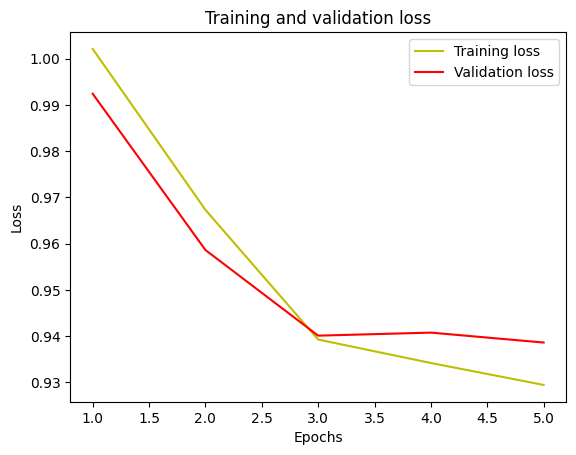

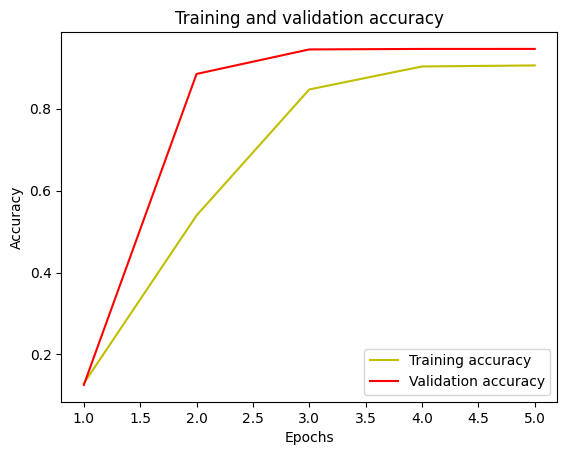

In [ ]:

loss = model_1.history['loss']
val_loss = model_1.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = model_1.history['accuracy']
val_acc = model_1.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loading the model and predict


In [ ]:
from keras.models import load_model
from keras.metrics import MeanIoU


my_model = load_model('/content/Model/lits.keras', compile=False)

test_img_dir = "/content/LITS_test/img_test/"
test_segm_dir = "/content/LITS_test/img_segm_test/"

test_img_list = os.listdir(test_img_dir)
test_segm_list = os.listdir(test_segm_dir)

batch_size = 1
test_img_datagen = imageLoader(test_img_dir, test_img_list,
                                test_segm_dir, test_segm_list, batch_size)

test_image_batch, test_mask_batch = test_img_datagen.__next__()
print(test_image_batch.shape)
print(test_mask_batch.shape)
test_mask_batch_argmax = np.argmax(test_mask_batch, axis=4)
test_pred_batch = my_model.predict(test_image_batch)
print(test_pred_batch.shape,'----')
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=4)

print(test_pred_batch_argmax.shape)
print(test_mask_batch_argmax.shape)

n_classes = 3
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)
print("Mean IoU =", IOU_keras.result().numpy())


(1, 256, 256, 64, 1)
(1, 256, 256, 64, 3)
1/1 [==============================] - 6s 6s/step
(1, 256, 256, 64, 3) ----
(1, 256, 256, 64)
(1, 256, 256, 64)
Mean IoU = 0.3324596


# Plotting a prediction

(256, 256, 64, 1)
(1, 256, 256, 64, 1)
(256, 256, 64, 3)
(1, 256, 256, 64, 3)
(1, 256, 256, 64)
1/1 [==============================] - 5s 5s/step
(1, 256, 256, 64, 3)
(1, 256, 256, 64)


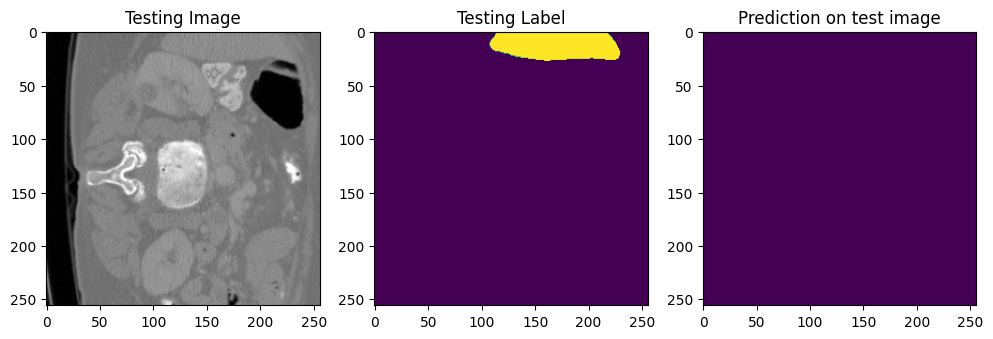

In [ ]:
#Try images:
img_num = 1  # make the number an image that is in the lits_test/img_test or img_seg_test/ they are from 41 to 50 for me

test_img = np.load("/content/LITS_test/img_test/"+"volume_"+str(img_num)+".npy")
print(test_img.shape)
test_img_input = np.expand_dims(test_img, axis=0)
print(test_img_input.shape)
test_mask = np.load("/content/LITS_test/img_segm_test/"+"segmentation_"+str(img_num)+".npy")
print(test_mask.shape)
test_mask_input = np.expand_dims(test_mask, axis=0)
print(test_mask_input.shape)
test_mask_argmax=np.argmax(test_mask_input, axis=4)
print(test_mask_argmax.shape)


test_prediction = my_model.predict(test_img_input)
print(test_prediction.shape)


test_prediction_argmax=np.argmax(test_prediction, axis=4)#[0,:,:,:]
print(test_prediction_argmax.shape)

#Plot individual slices from test predictions for verification
from matplotlib import pyplot as plt
import random

n_slice = random.randint(0, test_prediction_argmax.shape[3]-1)
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img_input[0,:,:,n_slice,0], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[0,:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[0,:,:, n_slice])
plt.show()


# Conclusions:



In this project, while the model did not achieve scores
comparable to the winners of the LiTS 2017 challenge, it
nonetheless demonstrated the potential and effectiveness of the
3D U-Net architecture for multi-class semantic segmentation
in biomedical imaging. By tailoring this sophisticated model to
address the unique demands of liver tumor segmentation, the
study aims to highlight the 3D U-Net’s adeptness in managing
the complexities of high-resolution, three-dimensional medical
scans. The endeavor contributes valuable insights to the ongoing
discourse on leveraging 3D U-Net as a formidable tool for
medical image analysis, especially pertinent in diagnosing and
planning treatment for liver diseases. However, the journey
unveiled the inherent challenges of preprocessing, training
duration, and constraints imposed by physical memory limitations,
which somewhat hindered achieving optimal results.
These findings signal critical areas for potential enhancements
in model training and optimization strategies, underscoring the
delicate task of balancing accuracy with precise localization
within volumetric segmentation endeavors. This experience
not only charts pathways for refining the model and its training
regimen but also fortifies the case for 3D U-Net’s applicability
in the nuanced sphere of medical imaging, with the prospect
of surmounting current limitations through focused improvements
and technological advancements.

